# Project 2 in numdiff


In [1]:
#Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Problem 1

In [2]:
#Create the partition 
def partition(X):  
    Tau_h = np.array([[a,(a+b)/2, b] for a, b in zip(X[0:-1], X[1:])])
    return Tau_h

# Define the phi derivatives functions
def phi0(x):
    return 2*x*x-3*x+1

def phi1(x):
    return -4*x*x+4*x

def phi2(x):
    return 2*x*x-x

# Define the global mapping function
def mapping(K, xi):
    h = K[2] - K[0]
    return K[0] + h*xi

# Define the local to global index mapping function
def local_to_global(k,a):
    return 2*k+a

#simpson algorithm from wikipedia
def simpson(f):
    return (1/6) * (f(0) + 4*f(0.5) + f(1))

#Matrix calculated from integrals in the overleaf document
def Ak(h):
    return 1/(3*h)* np.array([[7, -8, 1], [-8, 16 ,-8], [1, -8, 7]])


def Fk(f, K):
    fk = np.zeros(3)
    h = K[2] - K[0]
    fk[0] = h * simpson(lambda x : f(mapping(K,x))*phi0(x))
    fk[1] = h * simpson(lambda x : f(mapping(K,x))*phi1(x))
    fk[2] = h * simpson(lambda x : f(mapping(K,x))*phi2(x))
    return fk


#Makes the big Matrix
def assembly(partition, func):
    
    p = np.shape(partition)[0]
    m = 3*p - (p-1)
    A = np.zeros((m,m))
    F = np.zeros((m))

    # Loop over the elements of the partition
    for k in range(p):
        hk = partition[k][2] - partition[k][0]
        ak = Ak(hk)
        fk = Fk(func, partition[k])
        
        # Loop over the local basis functions
        # and fill in the global matrix and vector
        for alpha in range(3):
            i = local_to_global(k,alpha)
            for beta in range(3):
                j = local_to_global(k,beta)
                A[i][j] = A[i][j] + ak[alpha][beta]
            F[i] += fk[alpha]
    return A , F




#modifies the boundary of the big matrix
def modify_boundary(A):
    A[0] = np.zeros(len(A[0]))
    A[-1] = np.zeros(len(A[0]))
    A[0][0] = 1
    A[-1][-1] = 1
    return A

#modified the boundary of the vector for the np.linalg.solve
def modify_vector_boundary(v,a,b):
    v[0]=a
    v[len(v)-1]=b
    return v




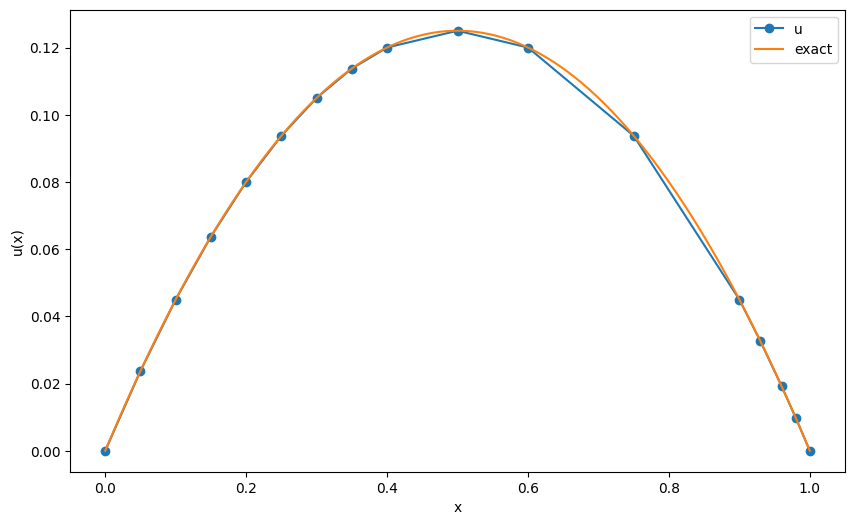

In [3]:

# Solve the problem with the given partition
def problem1(g, X, lbound=0,rbound=0): 
    # Create the partition
    tau = partition(X)
    
    #Creates the partition for plotting later
    Xi = []

    for i in range(len(X) - 1):
        Xi.append(X[i])  
        Xi.append((X[i] + X[i+1]) / 2)  

    Xi.append(X[-1])  # 


    a, F = assembly(tau, g)
    a = modify_boundary(a)

    F = modify_vector_boundary(F,lbound,rbound)
    # print("F:",F)
    u = np.linalg.solve(a,F)

    return u, Xi

# Plotting function for 
def plot_solution(u, Xi, exact_solution):

    plt.figure(figsize=(10, 6))
    x = np.linspace(0, 1, 100)
    plt.plot(Xi, u, "-o", label='u')
    plt.plot(x, exact_solution(x), label='exact')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.show()

# Simple function for testing
def g(x):
    return 1

#exact solution for comparison
def u_0(x):
    return -(1/2)*x*(x-1)



X = [0,0.1,0.2,0.3,0.4,0.6,0.9, 0.96,1]  

u, xi= problem1(g, X)

plot_solution(u, xi, u_0)



In [4]:
# Testing for different functions
def u_1(x):
    return np.sin(2*np.pi*x)

def u_1_derivative(x):
    return 2*np.pi*np.cos(2*np.pi*x)

def f_1(x):
    return 4*np.pi**2 * np.sin(2*np.pi*x)


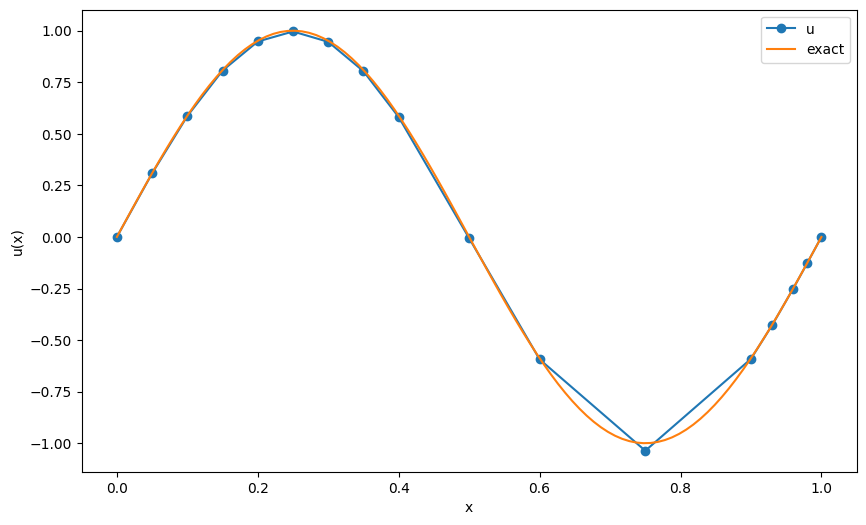

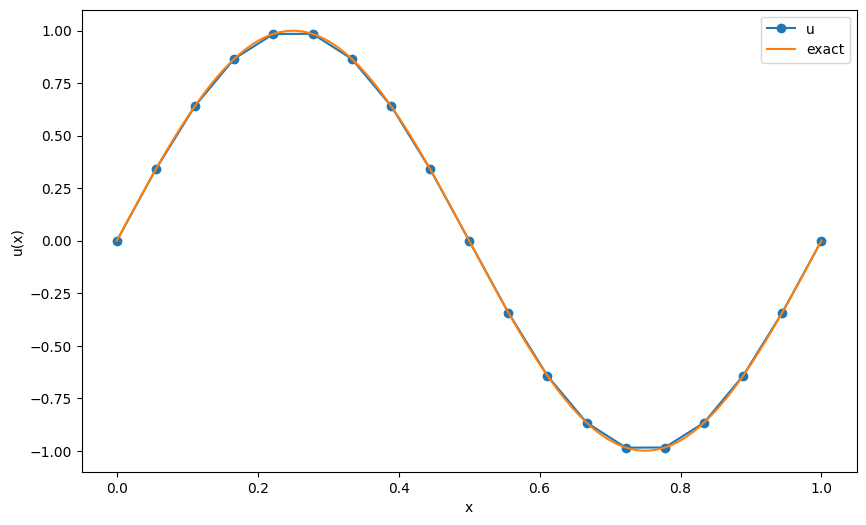

In [5]:

X = [0,0.1,0.2,0.3,0.4,0.6,0.9, 0.96,1]  
u, xi = problem1(f_1, X)

plot_solution(u, xi, u_1)


X = np.linspace(0,1,10)  # Testing a finer grid to see the effect on the solution

u, xi= problem1(f_1, X)

plot_solution(u, xi, u_1)

In [6]:
# Second test function with non zero boundary conditions
def u_2(x):
    return np.sin(x)

def u_2_derivative(x):
    return np.cos(x)

def f_2(x):
    return np.sin(x)

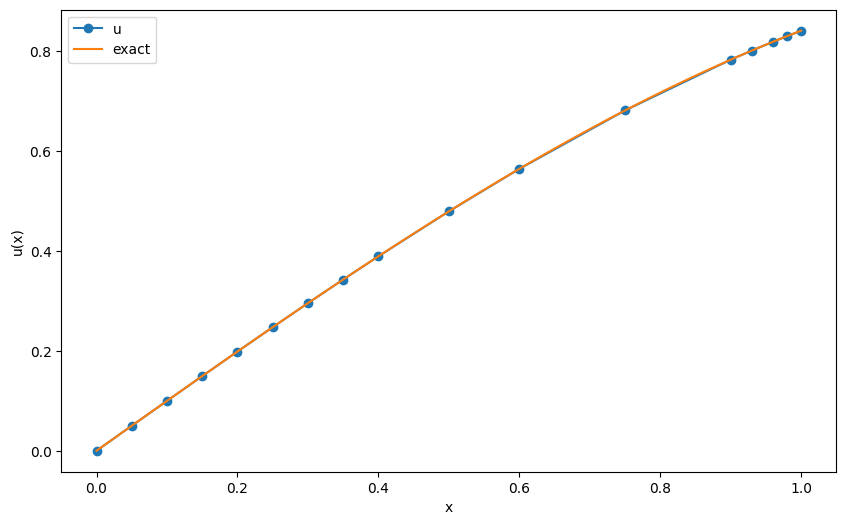

In [7]:

X = [0,0.1,0.2,0.3,0.4,0.6,0.9, 0.96,1]  
u, xi = problem1(f_2, X, u_2(0), u_2(1))

plot_solution(u, xi, u_2)

In [8]:
# Third test function with non zero boundary conditions
def u_3(x):
    return np.sin(x**2)

def u_3_derivative(x):
    return 2*x*np.cos(x**2)

def f_3(x):
    return -2*(np.cos(x**2) - 2*x**2*np.sin(x**2))

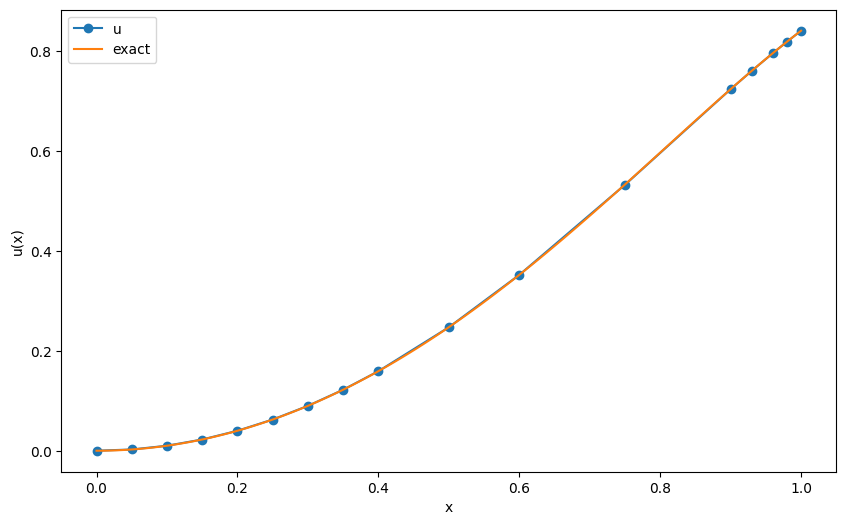

In [9]:
X = [0,0.1,0.2,0.3,0.4,0.6,0.9, 0.96,1]  
u, xi = problem1(f_3, X, u_3(0), u_3(1))

plot_solution(u, xi, u_3)

Mesh size (h) | L2 error ||u - u_h|| | Order of convergence
0.20000     | 5.54414e-03         | 3.59
0.10000     | 4.60946e-04         | 3.54
0.05000     | 3.95786e-05         | 3.51
0.02500     | 3.46888e-06         | 3.50
0.01250     | 3.05871e-07         | 3.50
0.00625     | 2.70169e-08         | 3.50
0.00313     | 2.39376e-09         | 3.51
Mesh size (h) | L2 error ||u - u_h|| | Order of convergence
0.20000     | 3.38907e-06         | 3.50
0.10000     | 2.98944e-07         | 3.50
0.05000     | 2.64096e-08         | 3.50
0.02500     | 2.33387e-09         | 3.50
0.01250     | 2.06478e-10         | 3.30
0.00625     | 2.09334e-11         | 2.40
0.00313     | 3.96414e-12         | -0.68
Mesh size (h) | L2 error ||u - u_h|| | Order of convergence
0.20000     | 1.03761e-04         | 3.53
0.10000     | 8.96954e-06         | 3.51
0.05000     | 7.88152e-07         | 3.50
0.02500     | 6.95577e-08         | 3.50
0.01250     | 6.14521e-09         | 3.50
0.00625     | 5.43335e-10         | 3.08

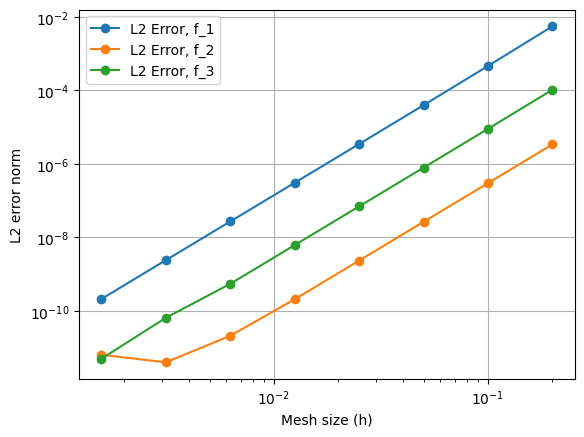

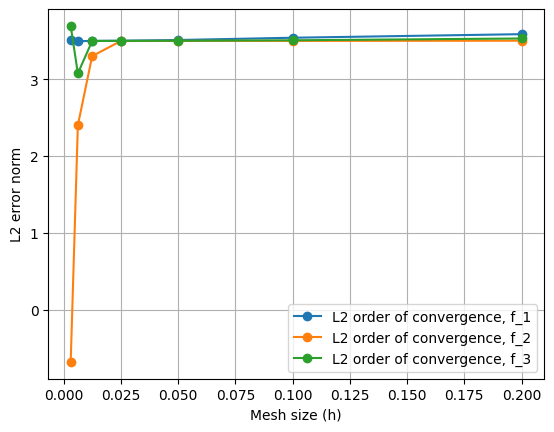

In [10]:


def compute_L2_error(u_h, nodes, exact_solution):
    error_integral = 0.0

    
    for i in range(0, len(nodes) - 2,2):
        
        error_left = (exact_solution(nodes[i]) - u_h[i])**2
        error_mid = (exact_solution(nodes[i+1]) - u_h[i+1] )**2
        error_right = (exact_solution(nodes[i+2]) - u_h[i+2])**2
        
        h = nodes[i+2] - nodes[i]
        error_integral += np.sqrt((h / 6) * (error_left + 4 * error_mid + error_right))
    
    return error_integral

def plot_l2_error(exact_solution,f):
    mesh_sizes = [1/5, 1/10, 1/20, 1/40, 1/80, 1/160, 1/320, 1/640]  
    errors = []

    for h in mesh_sizes:
        X = np.arange(0, 1 + h, h)  # Create partition
        u_h, nodes = problem1(f, X, exact_solution(0), exact_solution(1))  # Compute numerical solution
        error = compute_L2_error(u_h, nodes, exact_solution)
        errors.append(error)

    # Compute order of convergence
    orders = [np.log(errors[i] / errors[i+1]) / np.log(2) for i in range(len(errors) - 1)]



    # Print results
    print("Mesh size (h) | L2 error ||u - u_h|| | Order of convergence")
    for i in range(len(errors) -1):
        print(f"{mesh_sizes[i]:.5f}     | {errors[i]:.5e}         | {orders[i]:.2f}")

    # Plot error convergence
    plt.loglog(mesh_sizes, errors, "-o", label=f"L2 Error, {f.__name__}")
    plt.xlabel("Mesh size (h)")
    plt.ylabel("L2 error norm")
    plt.legend()
    plt.grid(True)
    

plot_l2_error(u_1,f_1)
plot_l2_error(u_2,f_2)
plot_l2_error(u_3,f_3)
plt.show()

def plot_l2_orderofconvergence(exact_solution,f):
    mesh_sizes = [1/5, 1/10, 1/20, 1/40, 1/80, 1/160, 1/320, 1/640]
    errors = []

    for h in mesh_sizes:
        X = np.arange(0, 1 + h, h)  # Create partition
        u_h, nodes = problem1(f, X, exact_solution(0), exact_solution(1))  # Compute numerical solution
        error = compute_L2_error(u_h, nodes, exact_solution)
        errors.append(error)

    # Compute order of convergence
    orders = [np.log(errors[i] / errors[i+1]) / np.log(2) for i in range(len(errors) - 1)]


    # Plot error convergence
    plt.plot(mesh_sizes[:-1], orders, "-o", label=f"L2 order of convergence, {f.__name__}")
    plt.xlabel("Mesh size (h)")
    plt.ylabel("L2 error norm")
    plt.legend()
    plt.grid(True)

plot_l2_orderofconvergence(u_1,f_1)
plot_l2_orderofconvergence(u_2,f_2)
plot_l2_orderofconvergence(u_3,f_3)
plt.show()


    


Mesh size (h) | H1 error ||u - u_h||_H1 | Order of convergence
0.20000     | 2.43348e+00         | 1.93
0.10000     | 6.38818e-01         | 1.98
0.05000     | 1.61683e-01         | 2.00
0.02500     | 4.05454e-02         | 2.00
0.01250     | 1.01442e-02         | 2.00
0.00625     | 2.53653e-03         | 2.00
0.00313     | 6.34164e-04         | 2.00
Mesh size (h) | H1 error ||u - u_h||_H1 | Order of convergence
0.20000     | 9.04877e-04         | 2.00
0.10000     | 2.26977e-04         | 2.00
0.05000     | 5.67916e-05         | 2.00
0.02500     | 1.42009e-05         | 2.00
0.01250     | 3.55040e-06         | 2.00
0.00625     | 8.87612e-07         | 2.00
0.00313     | 2.21904e-07         | 2.00
Mesh size (h) | H1 error ||u - u_h||_H1 | Order of convergence
0.20000     | 8.37169e-03         | 1.97
0.10000     | 2.13226e-03         | 1.99
0.05000     | 5.35565e-04         | 2.00
0.02500     | 1.34048e-04         | 2.00
0.01250     | 3.35218e-05         | 2.00
0.00625     | 8.38107e-06       

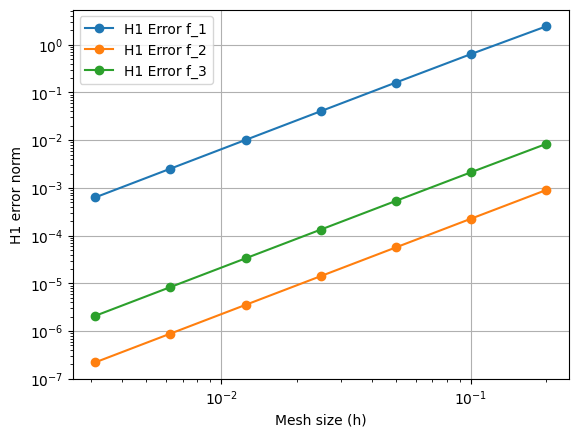

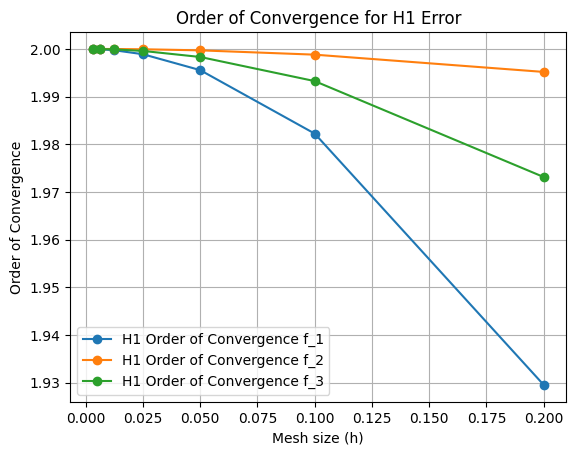

In [11]:

def compute_H1_error(u_h, nodes, exact_solution, exact_derivative):
    error_integral_L2 = 0.0
    error_integral_H1 = 0.0

    for i in range(0,len(nodes) - 2,2):
        
        error_left = (exact_solution(nodes[i]) - u_h[i])**2
        error_mid = (exact_solution(nodes[i+1]) - u_h[i+1] )**2
        error_right = (exact_solution(nodes[i+2]) - u_h[i+2])**2
        
        h = nodes[i+2] - nodes[i]
        error_integral_L2 += (h / 6) * (error_left + 4 * error_mid + error_right)
        
        # H1 semi-norm error (derivative part)
        uh_prime = (u_h[i+2] - u_h[i]) / h  # Numerical derivative (linear approx)
        
        error_deriv_left = (exact_derivative(nodes[i]) - uh_prime)**2
        error_deriv_mid = (exact_derivative(nodes[i+1]) - uh_prime)**2
        error_deriv_right = (exact_derivative(nodes[i+2]) - uh_prime)**2
        
        error_integral_H1 += (h / 6) * (error_deriv_left + 4 * error_deriv_mid + error_deriv_right)

    L2_error = error_integral_L2
    H1_seminorm_error = error_integral_H1
    
    H1_error = np.sqrt(L2_error**2 + H1_seminorm_error**2)
    
    return H1_error, L2_error, H1_seminorm_error

# Define exact derivative of the solution
def exact_solution_derivative(x):
    return - (x - 0.5)

# Compute H1 error for different mesh sizes
def plot_error(exact_solution, exact_solution_derivative, f):
    H1_errors = []
    L2_errors = []
    H1_seminorm_errors = []

    mesh_sizes = [1/5, 1/10, 1/20, 1/40, 1/80, 1/160, 1/320, 1/640]
    for h in mesh_sizes:
        X = np.arange(0, 1 + h, h)  # Create an equidistant partition
        u_h, nodes = problem1(f, X, exact_solution(0),exact_solution(1))  # Compute numerical solution
        
        H1_error, L2_error, H1_seminorm_error = compute_H1_error(u_h, nodes, exact_solution, exact_solution_derivative)
        
        H1_errors.append(H1_error)
        L2_errors.append(L2_error)
        H1_seminorm_errors.append(H1_seminorm_error)

    # Compute order of convergence
    H1_orders = [np.log(H1_errors[i] / H1_errors[i+1]) / np.log(2) for i in range(len(H1_errors) - 1)]

    # Print results
    print("Mesh size (h) | H1 error ||u - u_h||_H1 | Order of convergence")
    for i in range(len(H1_errors) - 1):
        print(f"{mesh_sizes[i]:.5f}     | {H1_errors[i]:.5e}         | {H1_orders[i]:.2f}")

    # Plot H1 error convergence
    plt.loglog(mesh_sizes[:-1], H1_errors[:-1], "-o", label=f"H1 Error {f.__name__}")
    plt.xlabel("Mesh size (h)")
    plt.ylabel("H1 error norm")
    plt.legend()
    plt.grid(True)
    

plot_error(u_1,u_1_derivative,f_1)
plot_error(u_2,u_2_derivative,f_2)
plot_error(u_3,u_3_derivative,f_3)
plt.show()


def plot_H1_order_convergence(exact_solution, exact_solution_derivative, f):
    H1_errors = []
    L2_errors = []
    H1_seminorm_errors = []

    mesh_sizes = [1/5, 1/10, 1/20, 1/40, 1/80, 1/160, 1/320, 1/640]
    for h in mesh_sizes:
        X = np.arange(0, 1 + h, h)  # Create an equidistant partition
        u_h, nodes = problem1(f, X, exact_solution(0),exact_solution(1))  # Compute numerical solution
        
        H1_error, L2_error, H1_seminorm_error = compute_H1_error(u_h, nodes, exact_solution, exact_solution_derivative)
        
        H1_errors.append(H1_error)
        L2_errors.append(L2_error)
        H1_seminorm_errors.append(H1_seminorm_error)

    # Compute order of convergence
    H1_orders = [np.log(H1_errors[i] / H1_errors[i+1]) / np.log(2) for i in range(len(H1_errors) - 1)]
    

    # Plot order of convergence
    plt.plot(mesh_sizes[:-1], H1_orders, "-o", label=f"H1 Order of Convergence {f.__name__}")
    plt.xlabel("Mesh size (h)")
    plt.ylabel("Order of Convergence")
    plt.legend()
    plt.grid(True)
    plt.title("Order of Convergence for H1 Error")
    

plot_H1_order_convergence(u_1,u_1_derivative,f_1)
plot_H1_order_convergence(u_2,u_2_derivative,f_2)
plot_H1_order_convergence(u_3,u_3_derivative,f_3)
plt.show()

## Problem 2


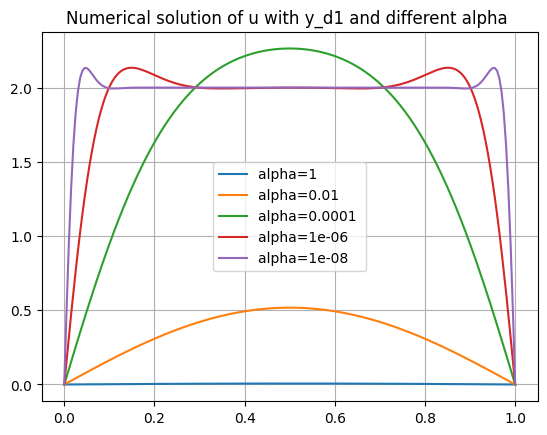

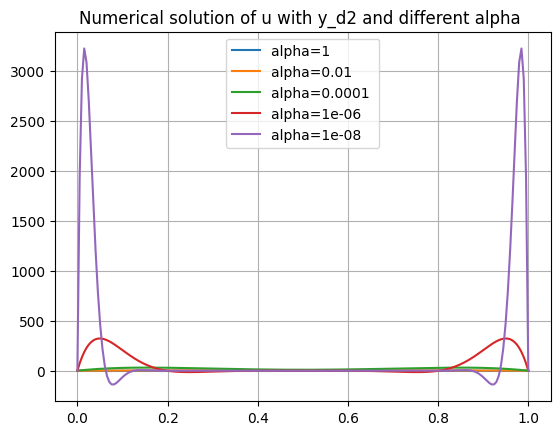

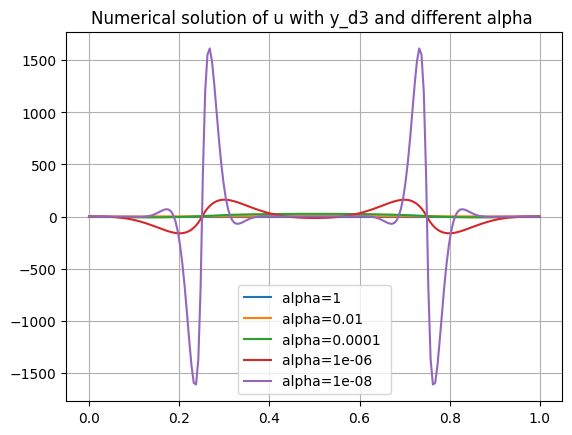

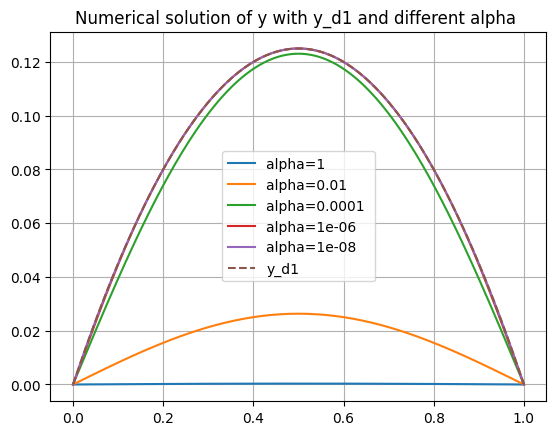

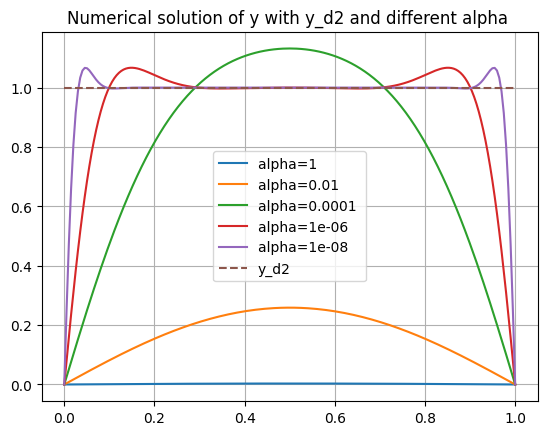

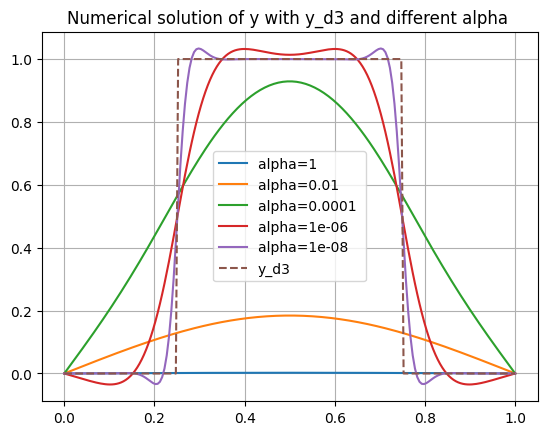

In [12]:

# Modified AK matrix for the second problem
# This is the same as the first one, but with different coefficients
def Ak2(h):
    return h/(15)* np.array([[2, 1, -1/2], [1, 8 , 1], [-1/2, 1, 2]])

# Modified Assembly function for the second problem
# This is the same as the first one, but without the integral of f
def assembly2(partition):
    p = np.shape(partition)[0]
    m = 3*p - (p-1)
    A = np.zeros((m,m))

    for k in range(p):
        hk = partition[k][1] - partition[k][0]
        ak = Ak2(hk)
        
        for alpha in range(3):
            i = local_to_global(k,alpha)
            for beta in range(3):
                j = local_to_global(k,beta)
                A[i][j] = A[i][j] + ak[alpha][beta]
            
    return A 

#Defining the different y_d functions
def y_d1(x):
    return (1/2)*x*(1-x)

def y_d2(x):
    return 1

def y_d3(x):
    if x >0.25 and x < 0.75:
        return 1
    else:
        return 0

#Solving the optimization problem for different alpha values and y_d functions
def optim(alpha, y_d):
    X = np.linspace(0, 1, 100)  # Create a finer grid for plotting


    tau = partition(X)
    
    combined = []

    for i in range(len(X) - 1):
        combined.append(X[i])  # Add original point
        combined.append((X[i] + X[i+1]) / 2)  # Add midpoint

    combined.append(X[-1])  # Add the last original point
    
    A = assembly2(tau)
    A = A[1:-1, 1:-1]

    Abar = assembly2(tau)
    Abar = Abar[:,1:-1]
    
    # g doesnt effect the result, as it only matters for F, which we dont use, 
    # we could have implemented a new function for g, but this gives us the same result
    Aprime, F = assembly(tau, g)
    Aprime = Aprime[1:-1, 1:-1]

    big_A = np.block([[A, np.zeros_like(A), -Aprime.T], 
                      [np.zeros_like(A), (alpha)*A, A.T],
                      [-Aprime, A.T, np.zeros_like(A)]])
    
    
    big_b = np.array([np.dot(Abar.T, [y_d(x) for x in combined])])
    big_b = np.append(big_b, np.zeros(len(A)*2))
    

    sol = np.linalg.solve(big_A, big_b)

    # Separete the solutions 
    y = sol[0:len(A)]
    u = sol[len(A):2*len(A)]
    lambda_ = sol[2*len(A):]
    # print("y:", y)
    # print("u", u)
    # print("lambda:", lambda_)
    return y, u, lambda_, combined


# Plotting function for the optimization problem
def plot_solution(u, y_d, combined, label=None):
    # plt.plot(combined[1:-1], y, "-", label='y')
    plt.plot(combined, np.pad(u, (1, 1),  constant_values=(0, 0)), "-", label = label)
    # plt.plot(combined[1:-1],lambda_, "-o", label='lambda')
    
    
    plt.legend()
    plt.grid()





# Different alphas for testing 
alphas = [1, 1e-2, 1e-4, 1e-6, 1e-8]

#Solution of u for y_d1
for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d1)
    plot_solution(u1, y_d1, X, label=f"alpha={alpha} ")
plt.title(f"Numerical solution of u with y_d1 and different alpha ")
plt.legend()
plt.show()

#Solution of u for y_d3
for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d2)
    plot_solution(u1, y_d2, X, label=f"alpha={alpha} ")
plt.title(f"Numerical solution of u with y_d2 and different alpha ")
plt.legend()
plt.show()

#Solution of u for y_d3
for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d3)
    plot_solution(u1, y_d3, X, label=f"alpha={alpha} ")
plt.title(f"Numerical solution of u with y_d3 and different alpha ")
plt.legend()
plt.show()

#Solution of y for y_d1
for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d1)
    plot_solution(y1, y_d1, X, label=f"alpha={alpha} ")

plt.plot(X, [y_d1(x) for x in X], "--", label='y_d1')

plt.title(f"Numerical solution of y with y_d1 and different alpha ")
plt.legend()
plt.show()

#Solution of y for y_d2
for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d2)
    plot_solution(y1, y_d2, X, label=f"alpha={alpha} ")

plt.plot(X, [y_d2(x) for x in X], "--", label='y_d2')
plt.title(f"Numerical solution of y with y_d2 and different alpha ")
plt.legend()
plt.show()

#Solution of y for y_d3
for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d3)
    plot_solution(y1, y_d3, X, label=f"alpha={alpha} ")

plt.plot(X, [y_d3(x) for x in X], "--", label='y_d3')
plt.title(f"Numerical solution of y with y_d3 and different alpha ")
plt.legend()
plt.show()
